# 0. Import Libs

In [1]:
import os
import zipfile
import kagglehub

import cv2
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from tensorflow.keras import (Sequential, Input, callbacks, layers, losses, 
metrics, utils, models, optimizers, regularizers)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.applications import VGG16
from keras.utils import image_dataset_from_directory

from sklearn.metrics import classification_report, confusion_matrix

2025-12-20 17:25:36.642271: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766251536.825960      25 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766251536.879577      25 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766251537.321960      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766251537.322003      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766251537.322006      25 computation_placer.cc:177] computation placer alr

# 1. Import Dataset

In [2]:
path = kagglehub.dataset_download("utkarshsaxenadn/fruits-classification")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/fruits-classification


# 2. Init Constants

In [3]:
CLASSES = ["Apple", "Banana", "Grape", "Mango", "Strawberry"]
BASE_DIR = "/kaggle/input/fruits-classification/Fruits Classification"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VALID_DIR = os.path.join(BASE_DIR, "valid")
TEST_DIR = os.path.join(BASE_DIR, "test")

IMG_SIZE = (256, 256)
IMG_CHANNELS = 3
BATCH_SIZE = 32
NUM_CLASSES = len(CLASSES)
WEIGHT_DECAY = 3e-4
INIT_LR = 5e-4

# 3. Create DataGenerator (with Augmentation)

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.1,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode="constant"
)

valid_datagen = ImageDataGenerator(rescale=1.0 / 255.0)
test_datagen  = ImageDataGenerator(rescale=1.0 / 255.0)

print("Train generator:")
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=True
)

print("\nValid generator:")
valid_generator = valid_datagen.flow_from_directory(
    VALID_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=False
)

print("\nTest generator:")
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=False
)

class_indices = train_generator.class_indices
print("\nclass_indices:", class_indices)

Train generator:
Found 9700 images belonging to 5 classes.

Valid generator:
Found 200 images belonging to 5 classes.

Test generator:
Found 100 images belonging to 5 classes.

class_indices: {'Apple': 0, 'Banana': 1, 'Grape': 2, 'Mango': 3, 'Strawberry': 4}


# 4. CNN Model

In [5]:
CNN = Sequential([
    Input(shape=(IMG_SIZE[0], IMG_SIZE[1], IMG_CHANNELS)),

    # FIRST CONV BLOCK
    layers.Conv2D(
        64, (3, 3), padding="same",
        kernel_regularizer=regularizers.l2(WEIGHT_DECAY),
        name="Conv2D_64"
    ),
    layers.BatchNormalization(name="BN_64"),
    layers.Activation("relu", name="ReLU_64"),
    layers.MaxPooling2D((2, 2), name="MaxPooling2D_64"),

    # SECOND CONV BLOCK
    layers.Conv2D(
        128, (3, 3), padding="same",
        kernel_regularizer=regularizers.l2(WEIGHT_DECAY),
        name="Conv2D_128"
    ),
    layers.BatchNormalization(name="BN_128"),
    layers.Activation("relu", name="ReLU_128"),
    layers.MaxPooling2D((2, 2), name="MaxPooling2D_128"),

    # THIRD CONV BLOCK
    layers.Conv2D(
        256, (3, 3), padding="same",
        kernel_regularizer=regularizers.l2(WEIGHT_DECAY),
        name="Conv2D_256"
    ),
    layers.BatchNormalization(name="BN_256"),
    layers.Activation("relu", name="ReLU_256"),
    layers.MaxPooling2D((2, 2), name="MaxPooling2D_256"),

    # Converting feature maps into a vector
    layers.GlobalAveragePooling2D(name="GlobalAveragePooling2D"),

    # DENSE PART
    layers.Dense(1024, activation="relu",
                 kernel_regularizer=regularizers.l2(WEIGHT_DECAY),
                 name="Dense_1024"),
    layers.Dropout(0.3, name="Dropout_1024_0.3"),

    layers.Dense(512, activation="relu",
                 kernel_regularizer=regularizers.l2(WEIGHT_DECAY),
                 name="Dense_"),
    layers.Dropout(0.25, name="Dropout_512_0.25"),


    # OUTOUT LAYER
    layers.Dense(NUM_CLASSES, activation="softmax", name="Final_Dense")
])
CNN.name = "CNN_Fruit_Classification"
CNN.summary()

I0000 00:00:1766251554.230993      25 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "CNN_Fruit_Classification"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv2D_64 (Conv2D)              │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN_64 (BatchNormalization)      │ (None, 256, 256, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ReLU_64 (Activation)            │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPooling2D_64 (MaxPooling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_128 (Conv2D)             │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN_128 (BatchNormalization)     │ (None, 128, 128, 128)  │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ReLU_128 (Activation)           │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPooling2D_128 (MaxPooling2D) │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_256 (Conv2D)             │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN_256 (BatchNormalization)     │ (None, 64, 64, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ReLU_256 (Activation)           │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPooling2D_256 (MaxPooling2D) │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GlobalAveragePooling2D          │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_1024 (Dense)              │ (None, 1024)           │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1024_0.3 (Dropout)      │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_ (Dense)                  │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_512_0.25 (Dropout)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Final_Dense (Dense)             │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,163,141 (4.44 MB)

 Trainable params: 1,162,245 (4.43 MB)

 Non-trainable params: 896 (3.50 KB)

In [6]:
INIT_LR = 5e-4

train_generator.reset()

CNN.compile(
    optimizer=optimizers.Adam(learning_rate=INIT_LR),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=[metrics.SparseCategoricalAccuracy(name="SCA")])
    
es = callbacks.EarlyStopping( monitor="val_loss", mode="min",
                             patience=8, restore_best_weights=True)

rlr = callbacks.ReduceLROnPlateau(monitor="val_loss", mode="min",
                                  factor=0.5, patience=2, min_lr=1e-6, verbose=1)


epochs = 50

history = CNN.fit(
    train_generator, epochs=epochs, validation_data=valid_generator,
    verbose=1, callbacks=[es, rlr])

CNN.save("/kaggle/working/cnn.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1766251559.987335      86 service.cc:152] XLA service 0x793dac107130 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1766251559.987371      86 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1766251560.628724      86 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/304 ━━━━━━━━━━━━━━━━━━━━ 28s 94ms/step - SCA: 0.2188 - loss: 2.0291   

I0000 00:00:1766251569.365408      86 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


304/304 ━━━━━━━━━━━━━━━━━━━━ 197s 608ms/step - SCA: 0.4153 - loss: 1.6923 - val_SCA: 0.3050 - val_loss: 2.1038 - learning_rate: 5.0000e-04
Epoch 2/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 138s 453ms/step - SCA: 0.5447 - loss: 1.3844 - val_SCA: 0.5650 - val_loss: 1.3571 - learning_rate: 5.0000e-04
Epoch 3/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 134s 440ms/step - SCA: 0.5675 - loss: 1.2829 - val_SCA: 0.5800 - val_loss: 1.2734 - learning_rate: 5.0000e-04
Epoch 4/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 131s 430ms/step - SCA: 0.5961 - loss: 1.2324 - val_SCA: 0.5350 - val_loss: 1.3513 - learning_rate: 5.0000e-04
Epoch 5/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - SCA: 0.6164 - loss: 1.1600
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
304/304 ━━━━━━━━━━━━━━━━━━━━ 137s 449ms/step - SCA: 0.6164 - loss: 1.1600 - val_SCA: 0.4850 - val_loss: 1.4348 - learning_rate: 5.0000e-04
Epoch 6/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 144s 474ms/step - SCA: 0.6403 - loss: 1.0879 - val_SCA: 0.6350 - val_loss

Best epoch: 40
Best train acc: 0.7497 (75.0%)
Best val acc: 0.7450 (74.5%)


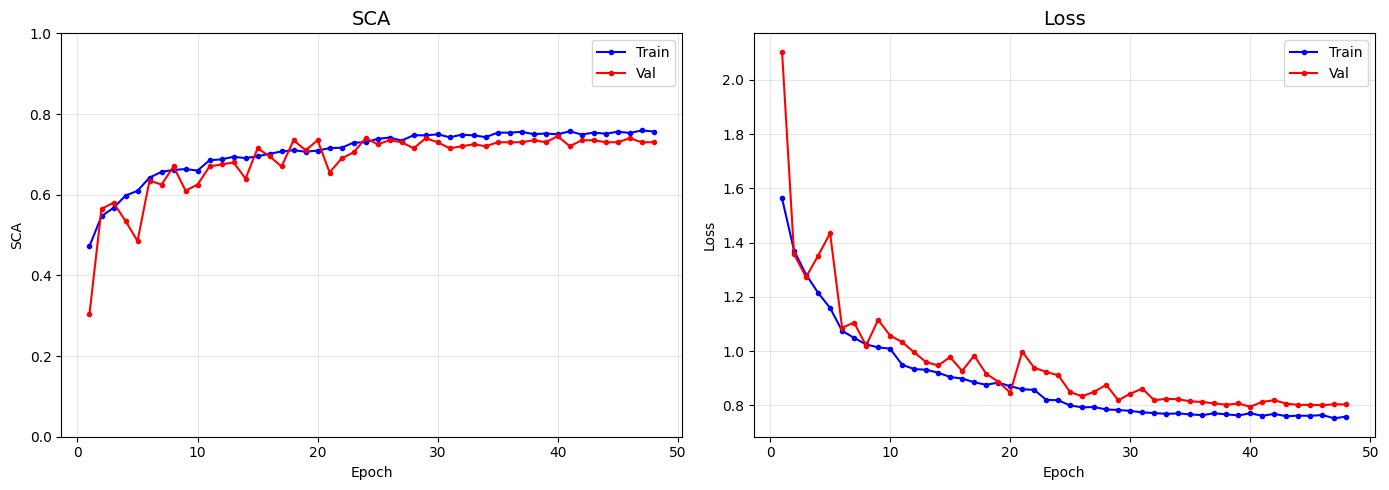

In [7]:
acc = history.history['SCA']
val_acc = history.history['val_SCA']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, acc, 'b-o', label='Train', markersize=3)
ax1.plot(epochs_range, val_acc, 'r-o', label='Val', markersize=3)
ax1.set_title('SCA', fontsize=14)
ax1.set_ylim([0, 1])
ax1.set_xlabel('Epoch')
ax1.set_ylabel('SCA')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, loss, 'b-o', label='Train', markersize=3)
ax2.plot(epochs_range, val_loss, 'r-o', label='Val', markersize=3)
ax2.set_title('Loss', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()

best_val_idx = np.argmax(val_acc)
print(f"Best epoch: {best_val_idx + 1}")
print(f"Best train acc: {acc[best_val_idx]:.4f} ({acc[best_val_idx]*100:.1f}%)")
print(f"Best val acc: {val_acc[best_val_idx]:.4f} ({val_acc[best_val_idx]*100:.1f}%)")


plt.show()

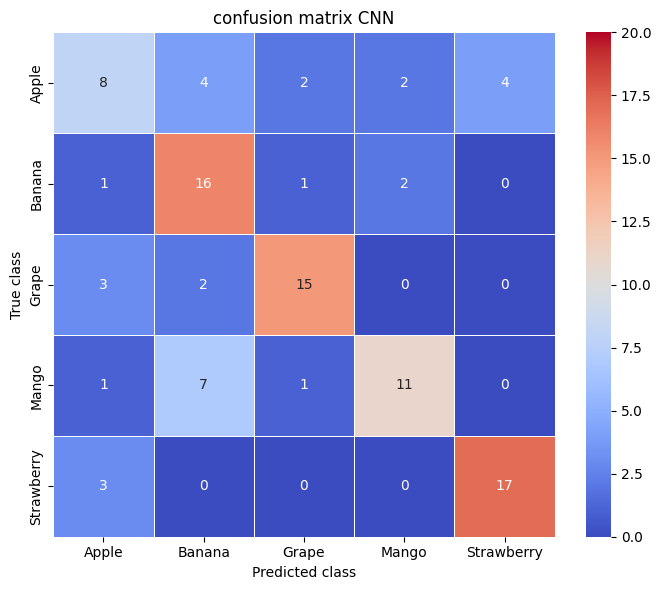


              precision    recall  f1-score   support

       Apple       0.50      0.40      0.44        20
      Banana       0.55      0.80      0.65        20
       Grape       0.79      0.75      0.77        20
       Mango       0.73      0.55      0.63        20
  Strawberry       0.81      0.85      0.83        20

    accuracy                           0.67       100
   macro avg       0.68      0.67      0.66       100
weighted avg       0.68      0.67      0.66       100



In [8]:
# CNN = models.load_model("/kaggle/output/cnn.keras")

test_generator.reset()

pred_probs = CNN.predict(test_generator, verbose=0)
pred_classes = np.argmax(pred_probs, axis=1)

true_classes = test_generator.classes

plt.figure(figsize=(7, 6))
cm = confusion_matrix(true_classes, pred_classes)
sns.heatmap(cm, vmin=0, vmax=20, annot=True, cmap="coolwarm", fmt='d',
                linewidths=0.5, xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('confusion matrix CNN')
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.tight_layout()
plt.show()

print("\n" + classification_report(true_classes, pred_classes, target_names=CLASSES))

# 5. Tranfer Model VGG16 (without Fine-Tunung)

In [9]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], IMG_CHANNELS)
)

base_model.summary()
print()

base_model.trainable = False

transfer_model = models.Sequential([
    # VGG16
    base_model,

    # Converting feature maps into a vector
    layers.GlobalAveragePooling2D(name="GlobalAveragePooling2D"),

    # DENSE PART
    layers.Dense(1024, activation="relu",
                 kernel_regularizer=regularizers.l2(WEIGHT_DECAY),
                 name="Dense_1024"),
    layers.Dropout(0.3, name="Dropout_1024_0.3"),

    layers.Dense(512, activation="relu",
                 kernel_regularizer=regularizers.l2(WEIGHT_DECAY),
                 name="Dense_"),
    layers.Dropout(0.25, name="Dropout_512_0.25"),


    # OUTOUT LAYER
    layers.Dense(NUM_CLASSES, activation="softmax", name="Final_Dense")
])

transfer_model.name = "VGG16_Fruit_Classification"
transfer_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

...

Model: "VGG16_Fruit_Classification"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 8, 8, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GlobalAveragePooling2D          │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_1024 (Dense)              │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1024_0.3 (Dropout)      │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_ (Dense)                  │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_512_0.25 (Dropout)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Final_Dense (Dense)             │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,767,365 (60.15 MB)

 Trainable params: 1,052,677 (4.02 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [10]:
train_generator.reset()
valid_generator.reset()

transfer_model.compile(
    optimizer=optimizers.Adam(learning_rate=INIT_LR),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=[metrics.SparseCategoricalAccuracy(name="SCA")])
    
es = callbacks.EarlyStopping( monitor="val_loss", mode="min",
                             patience=8, restore_best_weights=True)

rlr = callbacks.ReduceLROnPlateau(monitor="val_loss", mode="min",
                                  factor=0.5, patience=2, min_lr=1e-6, verbose=1)


epochs = 50

history = transfer_model.fit(
    train_generator, epochs=epochs, validation_data=valid_generator,
    verbose=1, callbacks=[es, rlr])

transfer_model.save("/kaggle/working/transfer_model.keras")

Epoch 1/50
 58/304 ━━━━━━━━━━━━━━━━━━━━ 1:54 465ms/step - SCA: 0.3073 - loss: 1.9542

2025-12-20 19:22:15.649513: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-20 19:22:15.904922: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


304/304 ━━━━━━━━━━━━━━━━━━━━ 167s 504ms/step - SCA: 0.4617 - loss: 1.6021 - val_SCA: 0.7150 - val_loss: 1.0059 - learning_rate: 5.0000e-04
Epoch 2/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 145s 476ms/step - SCA: 0.6733 - loss: 1.0656 - val_SCA: 0.6850 - val_loss: 0.9214 - learning_rate: 5.0000e-04
Epoch 3/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 147s 482ms/step - SCA: 0.6965 - loss: 0.9802 - val_SCA: 0.7300 - val_loss: 0.8847 - learning_rate: 5.0000e-04
Epoch 4/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 146s 480ms/step - SCA: 0.7214 - loss: 0.9158 - val_SCA: 0.7350 - val_loss: 0.8161 - learning_rate: 5.0000e-04
Epoch 5/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 145s 475ms/step - SCA: 0.7383 - loss: 0.8784 - val_SCA: 0.7200 - val_loss: 0.8093 - learning_rate: 5.0000e-04
Epoch 6/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 145s 477ms/step - SCA: 0.7353 - loss: 0.8621 - val_SCA: 0.7700 - val_loss: 0.7749 - learning_rate: 5.0000e-04
Epoch 7/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 145s 477ms/step - SCA: 0.7428 - loss: 0.8260 - val_SCA: 0.7300 - val_lo

Best epoch: 13
Best train acc: 0.7855 (78.5%)
Best val acc: 0.8000 (80.0%)


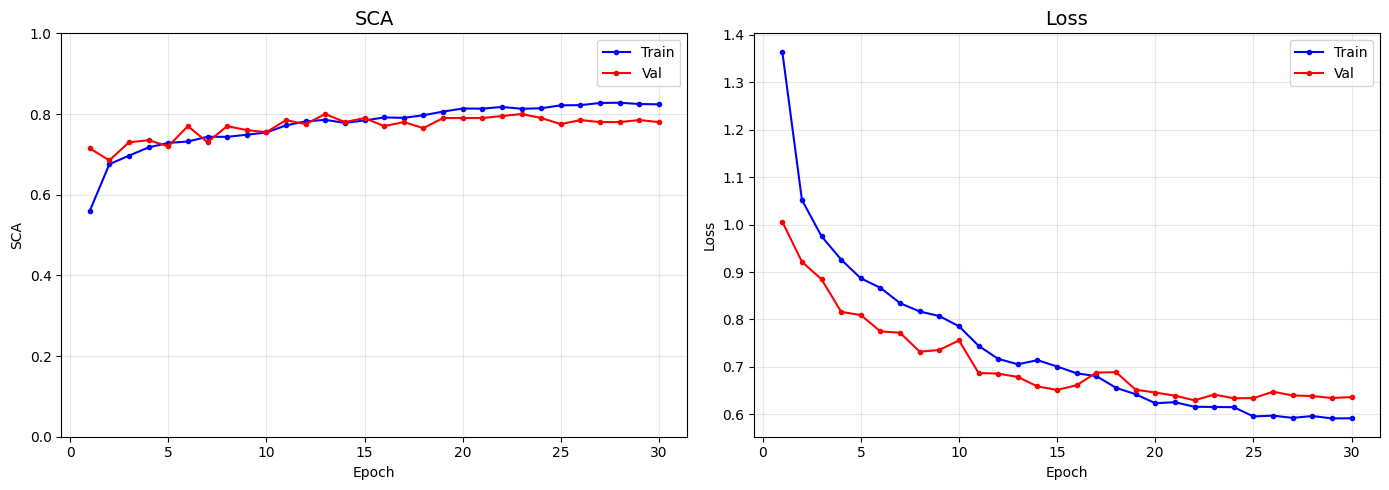

In [11]:
acc = history.history['SCA']
val_acc = history.history['val_SCA']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, acc, 'b-o', label='Train', markersize=3)
ax1.plot(epochs_range, val_acc, 'r-o', label='Val', markersize=3)
ax1.set_title('SCA', fontsize=14)
ax1.set_ylim([0, 1])
ax1.set_xlabel('Epoch')
ax1.set_ylabel('SCA')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, loss, 'b-o', label='Train', markersize=3)
ax2.plot(epochs_range, val_loss, 'r-o', label='Val', markersize=3)
ax2.set_title('Loss', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()

best_val_idx = np.argmax(val_acc)
print(f"Best epoch: {best_val_idx + 1}")
print(f"Best train acc: {acc[best_val_idx]:.4f} ({acc[best_val_idx]*100:.1f}%)")
print(f"Best val acc: {val_acc[best_val_idx]:.4f} ({val_acc[best_val_idx]*100:.1f}%)")


plt.show()

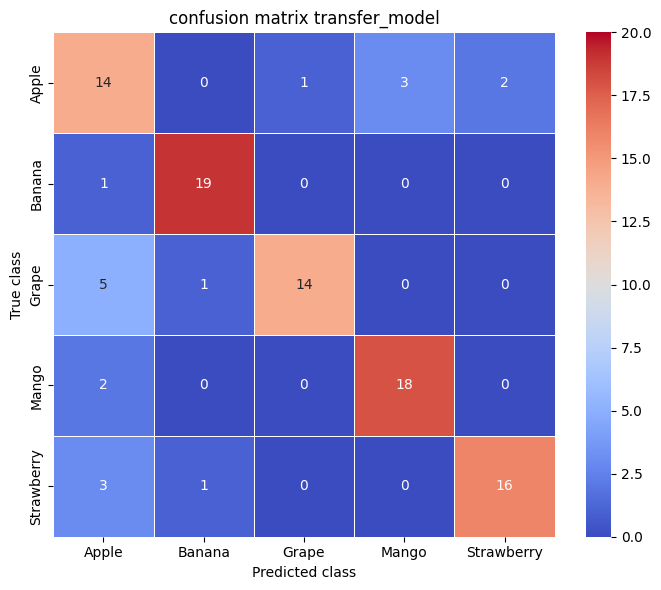


              precision    recall  f1-score   support

       Apple       0.56      0.70      0.62        20
      Banana       0.90      0.95      0.93        20
       Grape       0.93      0.70      0.80        20
       Mango       0.86      0.90      0.88        20
  Strawberry       0.89      0.80      0.84        20

    accuracy                           0.81       100
   macro avg       0.83      0.81      0.81       100
weighted avg       0.83      0.81      0.81       100



In [12]:
# transfer_model = models.load_model("/kaggle/output/transfer_model.keras")

test_generator.reset()

pred_probs = transfer_model.predict(test_generator, verbose=0)
pred_classes = np.argmax(pred_probs, axis=1)

true_classes = test_generator.classes

plt.figure(figsize=(7, 6))
cm = confusion_matrix(true_classes, pred_classes)
sns.heatmap(cm, vmin=0, vmax=20, annot=True, cmap="coolwarm", fmt='d',
                linewidths=0.5, xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('confusion matrix transfer_model')
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.tight_layout()
plt.show()

print("\n" + classification_report(true_classes, pred_classes, target_names=CLASSES))

# 6. Transfer Model VGG16 (with Fine-Tuning)

In [13]:
transfer_model_fine = models.load_model("/kaggle/working/transfer_model.keras")
base_model = transfer_model_fine.get_layer("vgg16")
base_model.trainable = True

train_generator.reset()
valid_generator.reset()

transfer_model_fine.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=[
          metrics.SparseCategoricalAccuracy(name="SCA")
    ]
)

es = callbacks.EarlyStopping(monitor="val_loss",
                             patience=5, restore_best_weights=True)

EPOCHS_FINE = 25
history_fine = transfer_model_fine.fit(
    train_generator,
    epochs=EPOCHS_FINE,
    validation_data=valid_generator,
    verbose=1,
    callbacks=[es])

Epoch 1/25
282/304 ━━━━━━━━━━━━━━━━━━━━ 10s 481ms/step - SCA: 0.8143 - loss: 0.6314

2025-12-20 20:35:40.259802: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-20 20:35:40.514877: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


304/304 ━━━━━━━━━━━━━━━━━━━━ 181s 511ms/step - SCA: 0.8160 - loss: 0.6270 - val_SCA: 0.8950 - val_loss: 0.4028
Epoch 2/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 146s 479ms/step - SCA: 0.8680 - loss: 0.4821 - val_SCA: 0.8950 - val_loss: 0.4229
Epoch 3/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 146s 478ms/step - SCA: 0.8986 - loss: 0.4200 - val_SCA: 0.9350 - val_loss: 0.3397
Epoch 4/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 145s 476ms/step - SCA: 0.9162 - loss: 0.3582 - val_SCA: 0.9600 - val_loss: 0.2675
Epoch 5/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 147s 484ms/step - SCA: 0.9192 - loss: 0.3496 - val_SCA: 0.9450 - val_loss: 0.2723
Epoch 6/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 149s 489ms/step - SCA: 0.9305 - loss: 0.3098 - val_SCA: 0.9400 - val_loss: 0.2685
Epoch 7/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 148s 487ms/step - SCA: 0.9358 - loss: 0.2989 - val_SCA: 0.9300 - val_loss: 0.2786
Epoch 8/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 145s 476ms/step - SCA: 0.9445 - loss: 0.2755 - val_SCA: 0.9400 - val_loss: 0.2858
Epoch 9/25
304/304 ━━━━━━━━━━━━━━━━

Best epoch: 53
Best train acc: 0.9851 (98.5%)
Best val acc: 0.9800 (98.0%)


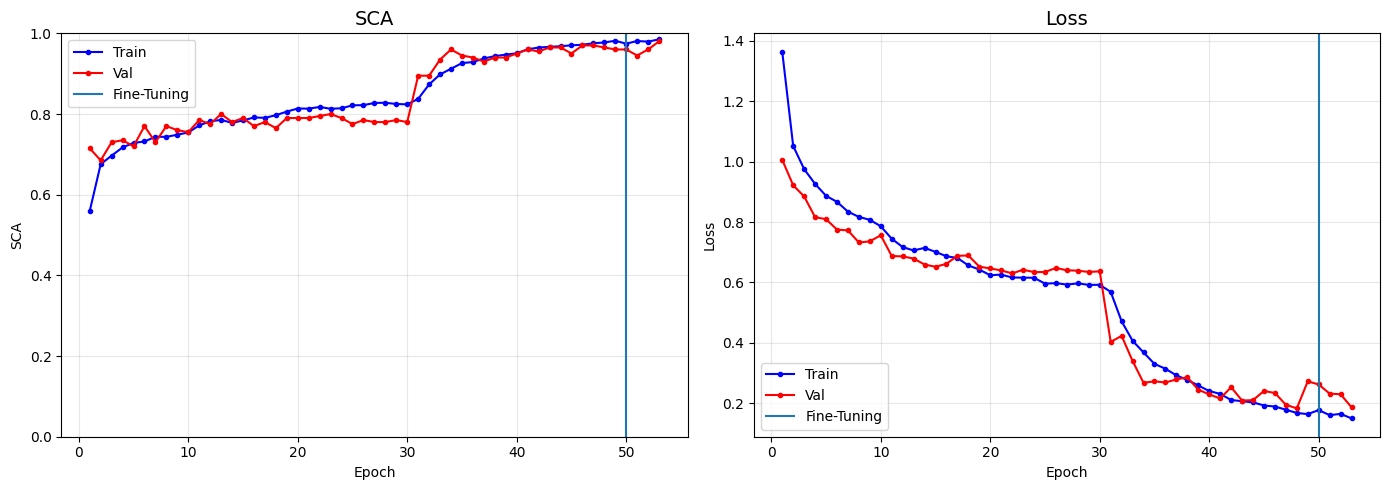

In [14]:
acc = history.history['SCA'] + history_fine.history['SCA']
val_acc = history.history['val_SCA'] + history_fine.history['val_SCA']
loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']
last_epoch = len(history.history['SCA'])
epochs_range = range(1, len(acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, acc, 'b-o', label='Train', markersize=3)
ax1.plot(epochs_range, val_acc, 'r-o', label='Val', markersize=3)
ax1.set_title('SCA', fontsize=14)
ax1.axvline(50, label="Fine-Tuning")
ax1.set_ylim([0, 1])
ax1.set_xlabel('Epoch')
ax1.set_ylabel('SCA')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, loss, 'b-o', label='Train', markersize=3)
ax2.plot(epochs_range, val_loss, 'r-o', label='Val', markersize=3)
ax2.set_title('Loss', fontsize=14)
ax2.axvline(50, label="Fine-Tuning")
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()

best_val_idx = np.argmax(val_acc)
print(f"Best epoch: {best_val_idx + 1}")
print(f"Best train acc: {acc[best_val_idx]:.4f} ({acc[best_val_idx]*100:.1f}%)")
print(f"Best val acc: {val_acc[best_val_idx]:.4f} ({val_acc[best_val_idx]*100:.1f}%)")


plt.show()

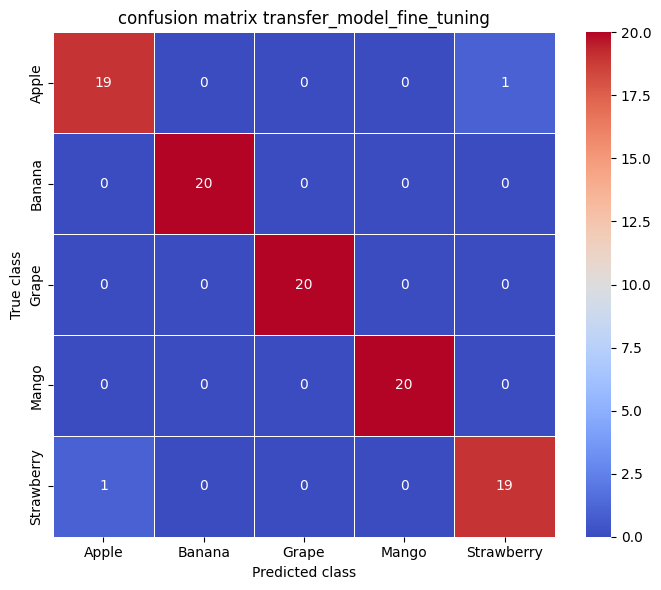


              precision    recall  f1-score   support

       Apple       0.95      0.95      0.95        20
      Banana       1.00      1.00      1.00        20
       Grape       1.00      1.00      1.00        20
       Mango       1.00      1.00      1.00        20
  Strawberry       0.95      0.95      0.95        20

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



In [15]:
# transfer_model = models.load_model("/kaggle/output/transfer_model.keras")

test_generator.reset()

pred_probs = transfer_model_fine.predict(test_generator, verbose=0)
pred_classes = np.argmax(pred_probs, axis=1)

true_classes = test_generator.classes

plt.figure(figsize=(7, 6))
cm = confusion_matrix(true_classes, pred_classes)
sns.heatmap(cm, vmin=0, vmax=20, annot=True, cmap="coolwarm", fmt='d',
                linewidths=0.5, xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('confusion matrix transfer_model_fine_tuning')
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.tight_layout()
plt.show()

print("\n" + classification_report(true_classes, pred_classes, target_names=CLASSES))